# Dependencias

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, pareto
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import genextreme,genpareto

# Simulación

Se simulan vectores aleatorios multivariados con cópulas y marginales arbitrarios.

In [3]:
np.random.seed(1984)

In [4]:
n = 100_000          # número de simulaciones
theta = 2            # parámetro de la cópula Clayton, theta > 0

alpha = 0.75        # parámetro de cola de la Pareto
xm = 1               # parámetro de escala de la Pareto

##  Función Copula

In [5]:
def simular_clayton(n, theta):
    """
    Simula n observaciones de una cópula Clayton bivariada.
    """

    W = np.random.gamma(shape=1/theta, scale=1, size=n)

    E1 = np.random.exponential(scale=1, size=n)
    E2 = np.random.exponential(scale=1, size=n)

    U1 = (1 + E1 / W)**(-1/theta)
    U2 = (1 + E2 / W)**(-1/theta)

    return U1, U2


In [6]:
U1, U2 = simular_clayton(n, theta)

## Marginales

In [7]:
X1 = norm.ppf(U1, loc=0, scale=1)

X2 = pareto.ppf(U2, b=alpha, scale=xm)

In [8]:
X = np.column_stack((X1, X2))

print(X[:10])

[[ -2.35550841   1.11041084]
 [ -1.56527413   1.09790152]
 [  0.22268225   1.61803281]
 [ -0.66611924   1.20215966]
 [  0.18500992   1.37159374]
 [ -1.6010496    1.05111578]
 [  0.17441422   3.89067732]
 [  1.11088627   5.24375026]
 [ -0.3417505    7.44594191]
 [  0.60308651 168.76071084]]


## Gráfica

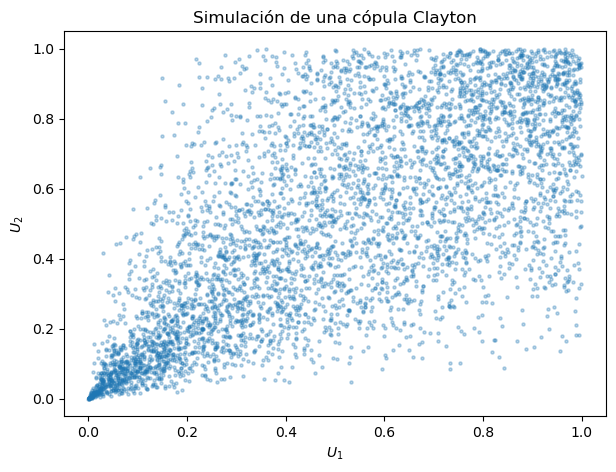

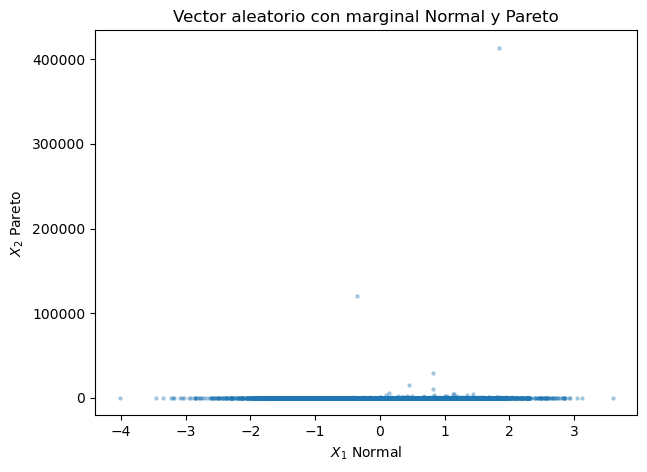

In [9]:
# ============================================================
# 6. Gráfica de la cópula
# ============================================================

plt.figure(figsize=(7, 5))
plt.scatter(U1[:5000], U2[:5000], s=5, alpha=0.3)
plt.xlabel(r"$U_1$")
plt.ylabel(r"$U_2$")
plt.title("Simulación de una cópula Clayton")
plt.show()


# ============================================================
# 7. Gráfica del vector aleatorio final
# ============================================================

plt.figure(figsize=(7, 5))
plt.scatter(X1[:5000], X2[:5000], s=5, alpha=0.3)
plt.xlabel(r"$X_1$ Normal")
plt.ylabel(r"$X_2$ Pareto")
plt.title("Vector aleatorio con marginal Normal y Pareto")
plt.show()

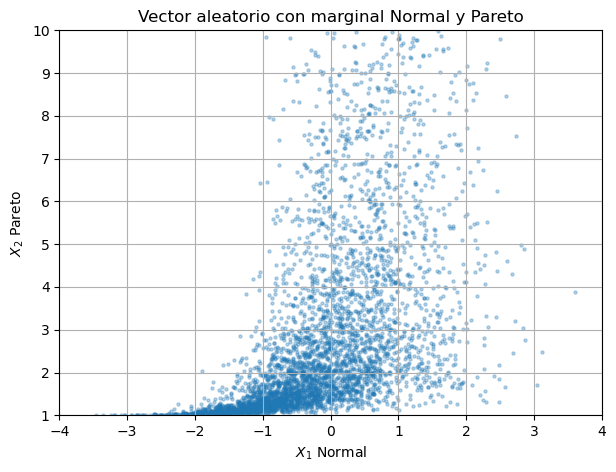

In [10]:
plt.figure(figsize=(7, 5))

plt.scatter(X1[:5000], X2[:5000], s=5, alpha=0.3)

plt.xlabel(r"$X_1$ Normal")
plt.ylabel(r"$X_2$ Pareto")
plt.title("Vector aleatorio con marginal Normal y Pareto")

plt.xlim(-4, 4)
plt.ylim(1, 10)

plt.grid(True)
plt.show()

# Máximo por bloques

In [12]:
block_size = 100
n = X.shape[0]
n_blocks = n // block_size
X_recortada = X[:n_blocks * block_size, :]
X_bloques = X_recortada.reshape(n_blocks, block_size, 2)
maximos_bloque = X_bloques.max(axis=1)


In [14]:
maximos_bloque

array([[2.20679945e+00, 2.29978165e+03],
       [2.86418807e+00, 1.19941957e+05],
       [2.93407147e+00, 4.40005497e+02],
       ...,
       [1.58608910e+00, 3.45128647e+02],
       [2.70854132e+00, 6.36948635e+02],
       [2.65957330e+00, 3.06239633e+02]])

In [15]:
maximos_bloque.shape

(1000, 2)

In [18]:
maximos_df = pd.DataFrame(
    maximos_bloque,
    columns=["M1_Normal", "M2_Pareto"]
)

In [20]:
print(maximos_df.head())
print(maximos_df.shape)

   M1_Normal      M2_Pareto
0   2.206799    2299.781647
1   2.864188  119941.956862
2   2.934071     440.005497
3   2.321216      97.187204
4   2.547431     454.220020
(1000, 2)


In [22]:
# Ajuste GEV a máximos por bloque
c1, loc1, scale1 = genextreme.fit(maximos_df["M1_Normal"])
c2, loc2, scale2 = genextreme.fit(maximos_df["M2_Pareto"])

In [23]:
u = genextreme.cdf(maximos_df["M1_Normal"], c1, loc=loc1, scale=scale1)
v = genextreme.cdf(maximos_df["M2_Pareto"], c2, loc=loc2, scale=scale2)

In [24]:
eps = 1e-10
u = np.clip(u, eps, 1 - eps)
v = np.clip(v, eps, 1 - eps)

In [25]:
def log_density_gumbel_extreme(u, v, theta):
    """
    Log-densidad de la cópula extrema Gumbel-Hougaard bivariada.
    theta >= 1.
    """
    
    x = -np.log(u)
    y = -np.log(v)
    
    S = x**theta + y**theta
    A = S**(1 / theta)
    
    log_C = -A
    
    log_c = (
        log_C
        + (theta - 1) * (np.log(x) + np.log(y))
        - np.log(u)
        - np.log(v)
        + (2 / theta - 2) * np.log(S)
        + np.log(A + theta - 1)
    )
    
    return log_c

In [26]:
def neg_log_likelihood(eta, u, v):
    """
    Negativa de la log-verosimilitud.
    Se usa theta = 1 + exp(eta) para garantizar theta >= 1.
    """
    
    theta = 1 + np.exp(eta[0])
    
    log_c = log_density_gumbel_extreme(u, v, theta)
    
    return -np.sum(log_c)

In [27]:
def neg_log_likelihood(eta, u, v):
    """
    Negativa de la log-verosimilitud.
    Se usa theta = 1 + exp(eta) para garantizar theta >= 1.
    """
    
    theta = 1 + np.exp(eta[0])
    
    log_c = log_density_gumbel_extreme(u, v, theta)
    
    return -np.sum(log_c)

In [29]:
resultado = minimize(
    neg_log_likelihood,
    x0=np.array([0.0]),
    args=(u, v),
    method="BFGS"
)

eta_hat = resultado.x[0]
theta_hat = 1 + np.exp(eta_hat)

print("Convergencia:", resultado.success)
print("Mensaje:", resultado.message)
print("theta estimado:", theta_hat)
print("Log-verosimilitud máxima:", -resultado.fun)

Convergencia: True
Mensaje: Optimization terminated successfully.
theta estimado: 1.000000011881809
Log-verosimilitud máxima: 5.834548430523728


# Construcción distribución de valores extremso bivariados

In [31]:
def copula_gumbel_extrema(u, v, theta):
    """
    Cópula extrema Gumbel-Hougaard bivariada.

    C_theta(u,v) = exp(-[((-log u)^theta + (-log v)^theta)^(1/theta)])

    theta >= 1
    theta = 1 implica independencia.
    """

    eps = 1e-10
    u = np.clip(u, eps, 1 - eps)
    v = np.clip(v, eps, 1 - eps)

    A = ((-np.log(u))**theta + (-np.log(v))**theta)**(1 / theta)

    return np.exp(-A)

In [32]:
def H_extrema_bivariada(x, y, c1, loc1, scale1, c2, loc2, scale2, theta):
    """
    Distribución bivariada de valores extremos estimada:

    H(x,y) = C_theta(G1(x), G2(y))
    """

    G1 = genextreme.cdf(x, c1, loc=loc1, scale=scale1)
    G2 = genextreme.cdf(y, c2, loc=loc2, scale=scale2)

    H = copula_gumbel_extrema(G1, G2, theta)

    return H

In [33]:
x_95 = maximos_df["M1_Normal"].quantile(0.95)
y_95 = maximos_df["M2_Pareto"].quantile(0.95)

H_95 = H_extrema_bivariada(
    x_95, y_95,
    c1, loc1, scale1,
    c2, loc2, scale2,
    theta_hat
)

print("Umbral 95% M1_Normal:", x_95)
print("Umbral 95% M2_Pareto:", y_95)
print("H(x_95, y_95) = P(M1 <= x_95, M2 <= y_95):", H_95)

Umbral 95% M1_Normal: 3.3048694380647627
Umbral 95% M2_Pareto: 24578.4906413716
H(x_95, y_95) = P(M1 <= x_95, M2 <= y_95): 0.8312698297742608


def prob_excedencia_conjunta(x, y, c1, loc1, scale1, c2, loc2, scale2, theta):
    """
    Calcula P(M1 > x, M2 > y)
    bajo la distribución extrema bivariada ajustada.
    """

    G1 = genextreme.cdf(x, c1, loc=loc1, scale=scale1)
    G2 = genextreme.cdf(y, c2, loc=loc2, scale=scale2)

    H = copula_gumbel_extrema(G1, G2, theta)

    p = 1 - G1 - G2 + H

    return p

In [35]:
p_exced_95 = prob_excedencia_conjunta(
    x_95, y_95,
    c1, loc1, scale1,
    c2, loc2, scale2,
    theta_hat
)

print("P(M1 > x_95, M2 > y_95):", p_exced_95)

P(M1 > x_95, M2 > y_95): 0.006434161891984758


In [36]:
q = 0.99

x_99 = genextreme.ppf(q, c1, loc=loc1, scale=scale1)
y_99 = genextreme.ppf(q, c2, loc=loc2, scale=scale2)

p_exced_99 = prob_excedencia_conjunta(
    x_99, y_99,
    c1, loc1, scale1,
    c2, loc2, scale2,
    theta_hat
)

print("Umbral 99% GEV M1:", x_99)
print("Umbral 99% GEV M2:", y_99)
print("P(M1 > x_99, M2 > y_99):", p_exced_99)

Umbral 99% GEV M1: 3.7244870293233565
Umbral 99% GEV M2: 2094520962.8319294
P(M1 > x_99, M2 > y_99): 0.00010000016225164554


# Método de Excesos

In [40]:
x1 = X[:, 0]
x2 = X[:, 1]
q_u = 0.95
u1 = np.quantile(x1, q_u)
u2 = np.quantile(x2, q_u)
# Excesos sobre umbral
exc1 = x1[x1 > u1] - u1
exc2 = x2[x2 > u2] - u2
# Ajuste GPD por máxima verosimilitud
xi1, loc1_pot, beta1 = genpareto.fit(exc1, floc=0)
xi2, loc2_pot, beta2 = genpareto.fit(exc2, floc=0)
print("===== POT X1 =====")
print("u1:", u1)
print("xi1:", xi1)
print("beta1:", beta1)
print("n_excesos_x1:", len(exc1))

print("\n===== POT X2 =====")
print("u2:", u2)
print("xi2:", xi2)
print("beta2:", beta2)
print("n_excesos_x2:", len(exc2))

===== POT X1 =====
u1: 1.651301804272943
xi1: -0.13503742743664568
beta1: 0.4873436773647756
n_excesos_x1: 5000

===== POT X2 =====
u2: 54.798839455639296
xi2: 1.3467660306597207
beta2: 74.33343629686846
n_excesos_x2: 5000


In [41]:
def pot_tail_prob(x, datos, u, xi, beta):
    """
    Estima P(X > x) usando POT-GPD.
    """
    p_u = np.mean(datos > u)

    if x <= u:
        return np.mean(datos > x)

    exceso = x - u
    return p_u * genpareto.sf(exceso, c=xi, loc=0, scale=beta)

In [42]:
niveles = [0.95, 0.975, 0.99, 0.995]

resultados_pot = []

for q in niveles:
    z1 = np.quantile(x1, q)
    z2 = np.quantile(x2, q)

    p1 = pot_tail_prob(z1, x1, u1, xi1, beta1)
    p2 = pot_tail_prob(z2, x2, u2, xi2, beta2)

    # Estimación empírica directa
    p_conj_emp = np.mean((x1 > z1) & (x2 > z2))

    # Aproximación por independencia extrema,
    # consistente con theta_hat ≈ 1 en la cópula extrema ajustada
    p_conj_pot = p1 * p2

    resultados_pot.append({
        "cuantil": q,
        "umbral_x1": z1,
        "umbral_x2": z2,
        "POT_P_X1_excede": p1,
        "POT_P_X2_excede": p2,
        "P_conj_empirica": p_conj_emp,
        "P_conj_POT_ind_extrema": p_conj_pot
    })

resultados_pot_df = pd.DataFrame(resultados_pot)

print(resultados_pot_df)

   cuantil  umbral_x1    umbral_x2  POT_P_X1_excede  POT_P_X2_excede  \
0    0.950   1.651302    54.798839         0.050000         0.050000   
1    0.975   1.976124   142.482172         0.024868         0.024675   
2    0.990   2.350080   482.034138         0.010159         0.009997   
3    0.995   2.614828  1266.709639         0.005013         0.004880   

   P_conj_empirica  P_conj_POT_ind_extrema  
0          0.00673                0.002500  
1          0.00168                0.000614  
2          0.00027                0.000102  
3          0.00005                0.000024  


In [43]:
lambda_U = 2 - 2**(1 / theta_hat)

print("theta_hat:", theta_hat)
print("lambda_U:", lambda_U)

theta_hat: 1.000000011881809
lambda_U: 1.6471684682883847e-08
